In [1]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 0 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 28s (374 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and d

### STEP 1. 데이터 다운로드 및 로드

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings
warnings.filterwarnings('ignore')

# 한글폰트
plt.rc('font', family='NanumBarunGothic')

path = kagglehub.dataset_download("zhangluyuan/ab-testing")

In [75]:
df = pd.read_csv(path + "/ab_data.csv")

print("데이터 모양:", df.shape)
df.head()

데이터 모양: (294478, 5)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


### STEP 2. 탐색적 데이터 분석 (EDA)

In [76]:
# 기본 정보 및 결측치 확인
print("=== 결측치 확인 ===")
print(df.isnull().sum())

=== 결측치 확인 ===
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


In [77]:
print("=== 데이터 크기 ===")
print(f"행 수(관측치 개수): {df.shape[0]:,}")
print(f"열 수(변수 개수): {df.shape[1]:,}")

print("\n=== 컬럼 정보 ===")
print(df.info())

print("\n=== 기술통계 ===")
display(df.describe(include='all').T)

=== 데이터 크기 ===
행 수(관측치 개수): 294,478
열 수(변수 개수): 5

=== 컬럼 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None

=== 기술통계 ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,294478.0,NaN,NaN,NaN,787974.124733,91210.823776,630000.0,709032.25,787933.5,866911.75,945999.0
timestamp,294478,294478,2017-01-16 12:40:24.467417,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group,294478,2,treatment,147276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landing_page,294478,2,old_page,147239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
converted,294478.0,NaN,NaN,NaN,0.119659,0.324563,0.0,0.0,0.0,0.0,1.0


**사용자별 A/B 테스트 기록을 약 29만 건 보유**

In [14]:
# 중복 유저 확인
n_total_users = len(df)
n_unique_users = df['user_id'].nunique()
print(f"\n전체 행 수: {n_total_users}, 유니크 유저 수: {n_unique_users}")
print(f"중복 기록 수: {n_total_users - n_unique_users}")


전체 행 수: 294478, 유니크 유저 수: 290584
중복 기록 수: 3894


In [17]:
# 컬럼별 데이터 타입 확인
for col in df.columns:
    print(f"\n[{col}]")
    print("dtype:", df[col].dtype)
    print("unique:", df[col].nunique())
    print("null:", df[col].isnull().sum())


[user_id]
dtype: int64
unique: 290584
null: 0

[timestamp]
dtype: object
unique: 294478
null: 0

[group]
dtype: object
unique: 2
null: 0

[landing_page]
dtype: object
unique: 2
null: 0

[converted]
dtype: int64
unique: 2
null: 0


In [20]:
display(df['group'].value_counts(), \
        df['landing_page'].value_counts(), \
        df['converted'].value_counts() )

,count
group,
treatment,147276
control,147202


,count
landing_page,
old_page,147239
new_page,147239


,count
converted,
0,259241
1,35237


group         → control / treatment  <br>
landing_page  → old_page / new_page  <br>
converted     → 0 / 1  <br>

In [21]:
print("=== 결측치 상세보기 ===")

missing_count = df.isnull().sum()

missing_ratio = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_ratio(%)': missing_ratio
})

display(
    missing_df
    .sort_values('missing_count', ascending=False)
)

=== 결측치 상세보기 ===


,missing_count,missing_ratio(%)
user_id,0,0.0
timestamp,0,0.0
group,0,0.0
landing_page,0,0.0
converted,0,0.0


In [28]:
# 행 자체의 중복 확인
print("=== 완전 중복 행 ===")

duplicate_rows = df.duplicated()

print("중복 행 수:", duplicate_rows.sum())
print("중복 비율:", round(duplicate_rows.mean() * 100, 2), "%")

display(
    df[df.duplicated(keep=False)]
    .sort_values(df.columns.tolist())
    .head(20)
)

=== 완전 중복 행 ===
중복 행 수: 0
중복 비율: 0.0 %


,user_id,timestamp,group,landing_page,converted


In [32]:
print("=== 사용자 중복 재확인 ===")

n_rows = len(df)
n_users = df['user_id'].nunique()

print(f"전체 행 수: {n_rows:,}")
print(f"고유 사용자 수: {n_users:,}")
print(f"중복 기록 수: {n_rows - n_users:,}")

user_counts = df['user_id'].value_counts()

duplicated_users = user_counts[user_counts > 1]
print(f"2회 이상 등장한 사용자: {len(duplicated_users):,}")

display(duplicated_users.head(10))

=== 사용자 중복 재확인 ===
전체 행 수: 294,478
고유 사용자 수: 290,584
중복 기록 수: 3,894
2회 이상 등장한 사용자: 3,894


,count
user_id,
752737,2
781280,2
767913,2
886060,2
731779,2
827432,2
677313,2
756804,2
671874,2


In [33]:
display(
    df[df['user_id'].isin(duplicated_users.index)]
    .sort_values('user_id')
    .head(30)
)

# -> 한 사용자가 여러 번 실험에 참여할 수 있는 데이터 구조인가?
# A/B 테스트가 사용자 단위 랜덤 배정이라면 일반적으로 한 사용자가 하나의 그룹에만 속하는 것이 기대됩니다.

,user_id,timestamp,group,landing_page,converted
213114,630052,2017-01-07 12:25:54.089486,treatment,old_page,1
230259,630052,2017-01-17 01:16:05.208766,treatment,new_page,0
251762,630126,2017-01-19 17:16:00.280440,treatment,new_page,0
22513,630126,2017-01-14 13:35:54.778695,treatment,old_page,0
11792,630137,2017-01-22 14:59:22.051308,control,new_page,0
183371,630137,2017-01-20 02:08:49.893878,control,old_page,0
255753,630320,2017-01-12 05:27:37.181803,treatment,old_page,0
207211,630320,2017-01-07 18:02:43.626318,control,old_page,0
110634,630471,2017-01-23 01:42:51.501851,control,old_page,0
96929,630471,2017-01-07 02:14:17.405726,control,new_page,0


In [35]:
# 사용자별 그룹 일관성 확인
user_group_count = (
    df.groupby('user_id')['group']
      .nunique()
)

multi_group_users = user_group_count[user_group_count > 1]

print("=== 사용자 그룹 일관성 ===")
print("여러 그룹에 등장한 사용자 수:", len(multi_group_users))

display(multi_group_users.head(5))

=== 사용자 그룹 일관성 ===
여러 그룹에 등장한 사용자 수: 1895


,group
user_id,
630320,2
630805,2
630871,2
630887,2
631008,2


(확인필요)
*   랜덤 배정 로직 문제
*   사용자 식별 문제
*   데이터 중복
*   실험 기간 중 재배정


In [43]:
# 유저 중복 제거 (첫 번째 기록 유지)
df = df.drop_duplicates(subset=['user_id'], keep='first')

In [44]:
# 그룹별 사용자 수 확인

print("=== 그룹별 사용자 수 ===")
g_counts = df.groupby('group')['user_id'].nunique()
print(g_counts)

print("\n비율")
print(
    (g_counts/g_counts.sum()*100).round(2)
)

=== 그룹별 사용자 수 ===
group
control      145232
treatment    145352
Name: user_id, dtype: int64

비율
group
control      49.98
treatment    50.02
Name: user_id, dtype: float64


-> 비교적 균형적

In [45]:
# 그룹별 랜딩페이지 확인
print("=== 그룹 × 랜딩페이지 교차표 ===")

cross_tab = pd.crosstab(
    df['group'],
    df['landing_page']
)

display(cross_tab)

=== 그룹 × 랜딩페이지 교차표 ===


landing_page,new_page,old_page
group,,
control,1006,144226
treatment,144314,1038


In [46]:
cross_ratio = pd.crosstab(
    df['group'],
    df['landing_page'],
    normalize='index'
) * 100

display(cross_ratio.round(2))

landing_page,new_page,old_page
group,,
control,0.69,99.31
treatment,99.29,0.71


#### 그룹-랜딩페이지 불일치 확인

In [78]:
# 그룹-랜딩페이지 무결성 검증

mismatch = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
]

print("=== 그룹-랜딩페이지 불일치 ===")
print(f"불일치 행 수: {len(mismatch):,}")
print(f"불일치 비율: {len(mismatch) / len(df) * 100:.4f}%")

display(mismatch.head(5))

=== 그룹-랜딩페이지 불일치 ===
불일치 행 수: 3,893
불일치 비율: 1.3220%


,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0


-> 실험군과 대조군에 의도하지 않은 페이지가 노출되었거나, 로그 수집 과정에서 그룹/페이지 정보가 잘못 기록되었을 가능성이 있다.

In [52]:
#  정상 매칭 데이터만 추출
# df = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
#               ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))]

# print(f"전처리 후 최종 유저 수: {len(df)}")

전처리 후 최종 유저 수: 288540


#### 범주형 변수의 이상값 확인

In [79]:
# 범주형 변수의 이상값 확인
categorical_cols = [
    'group',
    'landing_page',
    'converted'
]

for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== group ===
group
treatment    147276
control      147202
Name: count, dtype: int64

=== landing_page ===
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

=== converted ===
converted
0    259241
1     35237
Name: count, dtype: int64


#### 비즈니스 규칙 위반을 검증

In [80]:
# 논리적 무결성 검증
# 서로 모순되는 데이터 확인 (비즈니스 규칙 위반을 검증)

# group과 landing_page 조합별 데이터 확인
logic_check = (
    df.groupby(['group', 'landing_page'])
      .size()
      .reset_index(name='count')
)
display(logic_check)

valid_pairs = {
    ('control', 'old_page'),
    ('treatment', 'new_page')
}

invalid_pair_mask = ~df[['group', 'landing_page']].apply(
    tuple,
    axis=1
).isin(valid_pairs)

print("논리적으로 잘못된 조합:", invalid_pair_mask.sum())

,group,landing_page,count
0,control,new_page,1928
1,control,old_page,145274
2,treatment,new_page,145311
3,treatment,old_page,1965


논리적으로 잘못된 조합: 3893


#### 전환율 확인

In [81]:
# 전환율 확인
conversion_summary = (
    df.groupby('group')
      .agg(
          users=('user_id', 'nunique'),
          conversions=('converted', 'sum')
      )
)

conversion_summary['conversion_rate'] = (
    conversion_summary['conversions']
    / conversion_summary['users']
)

display(conversion_summary)

,users,conversions,conversion_rate
group,,,
control,146195,17723,0.121228
treatment,146284,17514,0.119726


In [82]:
conversion_summary['conversion_rate_pct'] = (
    conversion_summary['conversion_rate'] * 100
).round(2)

display(conversion_summary)

,users,conversions,conversion_rate,conversion_rate_pct
group,,,,
control,146195,17723,0.121228,12.12
treatment,146284,17514,0.119726,11.97


In [83]:
# 차이 계산
control_rate = conversion_summary.loc[
    'control', 'conversion_rate'
]

treatment_rate = conversion_summary.loc[
    'treatment', 'conversion_rate'
]

absolute_diff = treatment_rate - control_rate

relative_diff = (
    treatment_rate / control_rate - 1
)

print(f"절대(Treatment - Control) 전환율 차이: {absolute_diff:.4%}")
print(f"상대 전환율 변화: {relative_diff:.2%}")

절대(Treatment - Control) 전환율 차이: -0.1502%
상대 전환율 변화: -1.24%


In [84]:
# 이상치 확인

numeric_cols = df.select_dtypes(
    include=np.number
).columns

display(
    df[numeric_cols].describe().T
)

def check_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower': lower,
        'upper': upper,
        'outlier_count': len(outliers),
        'outlier_ratio': len(outliers) / len(df)
    }

print()

for col in numeric_cols:
    print(col, check_outliers_iqr(df, col))

,count,mean,std,min,25%,50%,75%,max
user_id,294478.0,787974.124733,91210.823776,630000.0,709032.25,787933.5,866911.75,945999.0
converted,294478.0,0.119659,0.324563,0.0,0.00,0.0,0.00,1.0



user_id {'Q1': np.float64(709032.25), 'Q3': np.float64(866911.75), 'IQR': np.float64(157879.5), 'lower': np.float64(472213.0), 'upper': np.float64(1103731.0), 'outlier_count': 0, 'outlier_ratio': 0.0}
converted {'Q1': np.float64(0.0), 'Q3': np.float64(0.0), 'IQR': np.float64(0.0), 'lower': np.float64(0.0), 'upper': np.float64(0.0), 'outlier_count': 35237, 'outlier_ratio': 0.11965919355605512}


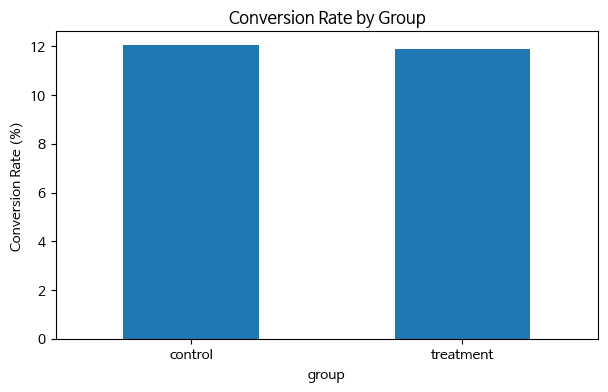

In [85]:
# 그룹별 전환율 시각화
conversion_rate = (
    df.groupby('group')['converted']
      .mean()
      .mul(100)
)

conversion_rate.plot(
    kind='bar',
    figsize=(7, 4)
)

plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Group')
plt.xticks(rotation=0)
plt.show()

In [86]:
# 날짜별 계산
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek

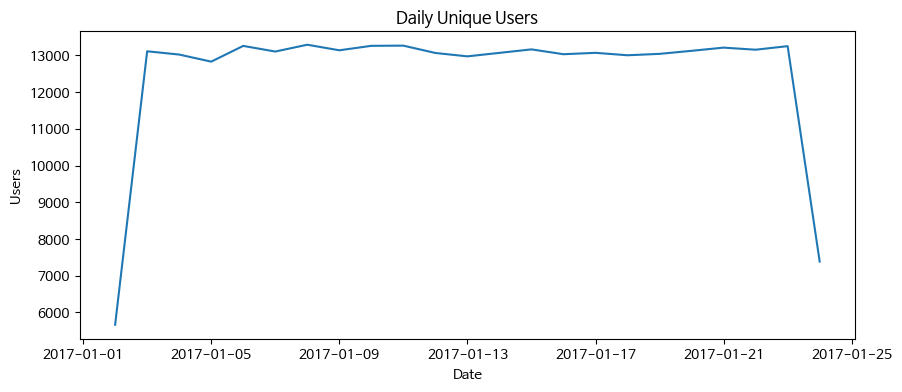

In [72]:
# 일별 사용자 수:
daily_users = (
    df.groupby('date')['user_id']
      .nunique()
)

daily_users.plot(figsize=(10, 4))

plt.title('Daily Unique Users')
plt.xlabel('Date')
plt.ylabel('Users')
plt.show()

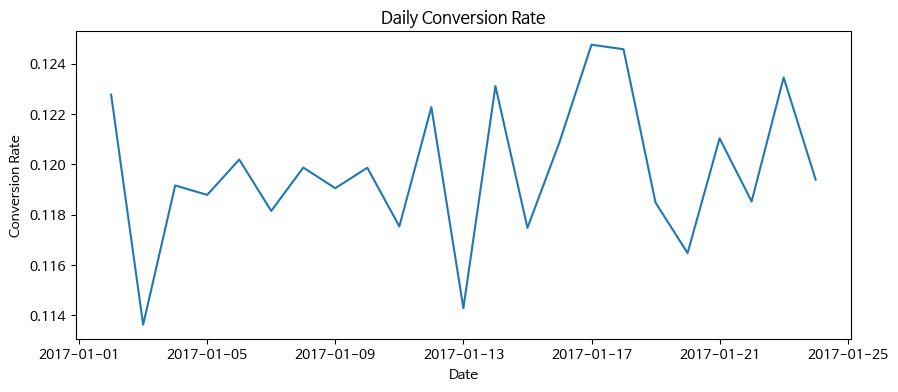

In [87]:
# 일별 전환율:
daily_conversion = (
    df.groupby('date')['converted']
      .mean()
)

daily_conversion.plot(figsize=(10, 4))

plt.title('Daily Conversion Rate')
plt.xlabel('Date')
plt.ylabel('Conversion Rate')
plt.show()

- 특정 날짜에 데이터가 급격히 감소했는가?
- 특정 날짜에 전환율이 비정상적으로 변했는가?
- 실험 초반/후반에 데이터 품질 문제가 있었는가?

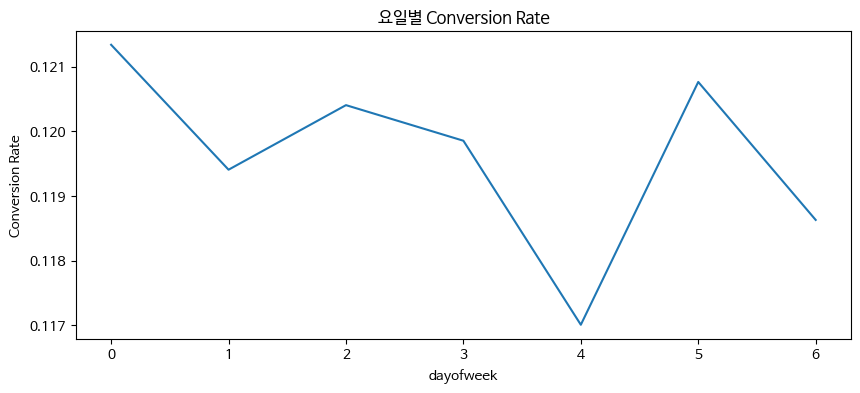

In [88]:
# 요일별 전환율:
daily_conversion = (
    df.groupby('dayofweek')['converted']
      .mean()
)

daily_conversion.plot(figsize=(10, 4))

plt.title('요일별 Conversion Rate')
plt.xlabel('dayofweek')
plt.ylabel('Conversion Rate')
plt.show()

### STEP 3. 데이터 전처리 (Data Preprocessing)
전처리에서는 다음 3가지를 반드시 수행합니다.

- 불일치 데이터 제거: control인데 new_page를 본 경우 등 오류 데이터 제거
- 중복 유저 정제: 동일 유저가 여러 번 기록된 경우 첫 접속 기록만 남김
- SRM (Sample Ratio Mismatch) 검정: 유저가 1:1 비율로 무작위 배정되었는지 카이제곱 검정으로 확인

In [89]:
# 1. 정상 매칭 데이터만 추출
df_clean = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
              ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))].copy()

# 2. 유저 중복 제거 (첫 번째 기록 유지)
df_clean = df_clean.drop_duplicates(subset=['user_id'], keep='first')

print(f"전처리 후 최종 유저 수: {len(df_clean)}")

# 3. SRM 검정 (Sample Ratio Mismatch)
# 1:1 무작위 배정 검증 (p < 0.01 이면 트래킹 이상 의심)
group_counts = df_clean['group'].value_counts()
chi2_srm, p_srm = stats.chisquare(group_counts.values, f_exp=[len(df_clean)/2, len(df_clean)/2])

print(f"\n[SRM 검정] chi2: {chi2_srm:.4f}, p-value: {p_srm:.4f}")
if p_srm < 0.01:
    print("⚠️ SRM 의심: 두 그룹의 배정 비율이 유의하게 다릅니다. 실험 시스템을 재검토하세요.")
else:
    print("✅ SRM 없음: 1:1 샘플 할당이 정상적으로 수행되었습니다.")

전처리 후 최종 유저 수: 290584

[SRM 검정] chi2: 0.0045, p-value: 0.9468
✅ SRM 없음: 1:1 샘플 할당이 정상적으로 수행되었습니다.


### STEP 4. 통계 검정 (Two-Sample Z-Test & Chi-Square)
전환율(0 또는 1)은 이항분포를 따르므로 2-Sample Z-Test 또는 카이제곱 검정(Chi-Square Test)을 사용합니다.
- 귀무가설 ($H_0$): 신규 페이지의 전환율은 기존 페이지와 차이가 없다 ($p_{new} \le p_{old}$)
- 대립가설 ($H_1$): 신규 페이지의 전환율이 기존 페이지보다 높다 ($p_{new} > p_{old}$)

In [91]:
# 그룹별 전환율 요약
summary = df_clean.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
summary.columns = ['Total_Users', 'Converted_Users', 'Conversion_Rate']
print("=== 그룹별 전환율 ===")
print(summary)

# Two-Sample Z-Test 수행
n_control = summary.loc['control', 'Total_Users']
n_treatment = summary.loc['treatment', 'Total_Users']
succ_control = summary.loc['control', 'Converted_Users']
succ_treatment = summary.loc['treatment', 'Converted_Users']

# scipy.stats 이용 z-검정
p_pooled = (succ_control + succ_treatment) / (n_control + n_treatment)
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_control + 1/n_treatment))
z_stat = (summary.loc['treatment', 'Conversion_Rate'] - summary.loc['control', 'Conversion_Rate']) / se
p_val_twosided = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"\n[Z-검정] Z-statistic: {z_stat:.4f}, p-value (양측): {p_val_twosided:.4f}")

=== 그룹별 전환율 ===
           Total_Users  Converted_Users  Conversion_Rate
group                                                   
control         145274            17489         0.120386
treatment       145310            17264         0.118808

[Z-검정] Z-statistic: -1.3109, p-value (양측): 0.1899


1. Z-통계량 (Z-statistic = -1.3109)
- 음수값($-$)은 Treatment 그룹의 전환율이 Control 그룹보다 낮음을 나타냅니다.
- 절댓값($1.3109$)은 표준정규분포 기준에서 표준편차의 약 1.31배 정도 떨어진 위치에 있음을 의미합니다.

2. p-값 (p-value = 0.1899)
- 일반적인 통계적 유의수준인 $\alpha = 0.05$ (5%)보다 훨씬 높습니다 ($0.1899 > 0.05$).
- 해석: "신규 페이지와 기존 페이지 간에 실제로 아무런 차이가 없다"는 귀무가설 하에서, 단지 우연한 무작위 오차만으로 0.16%p 수준의 차이가 관찰될 확률이 약 19%나 된다는 뜻입니다.

**통계적 유의성 부재: $p > 0.05$이므로, 신규 랜딩페이지가 전환율을 유의미하게 변화시켰다고 볼 통계적 근거가 없습니다.**

### STEP 5. 효과크기 및 부트스트랩 (Bootstrap & Effect Size)
p-value가 유의하더라도 실제 차이가 사업성에 의미가 있는지(Practical Significance) 판단해야 합니다.

- Cohen's h: 두 비율 차이에 대한 표준화된 효과크기
- 부트스트랩(Vectorized Bootstrap): 전환율 차이의 95% 신뢰구간 추정

In [92]:
# 1. Cohen's h 계산 (0.2=작음, 0.5=중간, 0.8=큼)
p1 = summary.loc['control', 'Conversion_Rate']
p2 = summary.loc['treatment', 'Conversion_Rate']
cohens_h = 2 * np.arcsin(np.sqrt(p2)) - 2 * np.arcsin(np.sqrt(p1))
print(f"Cohen's h 효과크기: {cohens_h:.4f}")

# 2. 벡터화 부트스트랩 (2,000회 반복)
rng = np.random.default_rng(42)
n_iter = 2000

ctrl_vals = df_clean[df_clean['group'] == 'control']['converted'].values
treat_vals = df_clean[df_clean['group'] == 'treatment']['converted'].values

idx_ctrl = rng.integers(0, len(ctrl_vals), size=(n_iter, len(ctrl_vals)))
idx_treat = rng.integers(0, len(treat_vals), size=(n_iter, len(treat_vals)))

boot_ctrl = ctrl_vals[idx_ctrl].mean(axis=1)
boot_treat = treat_vals[idx_treat].mean(axis=1)
boot_diff = boot_treat - boot_ctrl  # (Treatment - Control)

ci_low, ci_high = np.percentile(boot_diff, [2.5, 97.5])
print(f"전환율 차이 (Treatment - Control) 95% 신뢰구간: [{ci_low*100:+.3f}%p, {ci_high*100:+.3f}%p]")

Cohen's h 효과크기: -0.0049
전환율 차이 (Treatment - Control) 95% 신뢰구간: [-0.388%p, +0.082%p]


### STEP 6. 시각화 및 최종 결론

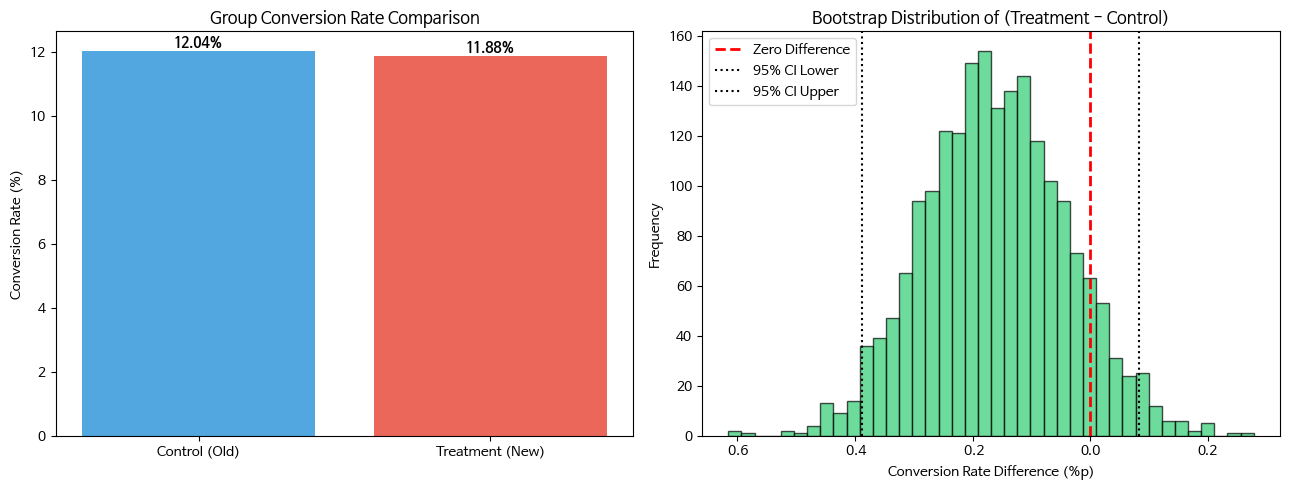

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. 막대그래프 (그룹별 전환율)
axes[0].bar(['Control (Old)', 'Treatment (New)'],
            [p1 * 100, p2 * 100],
            color=['#3498db', '#e74c3c'], alpha=0.85)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Group Conversion Rate Comparison')
for i, v in enumerate([p1 * 100, p2 * 100]):
    axes[0].text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold')

# 2. 부트스트랩 차이 분포 히스토그램
axes[1].hist(boot_diff * 100, bins=40, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Difference')
axes[1].axvline(ci_low * 100, color='black', linestyle=':', label='95% CI Lower')
axes[1].axvline(ci_high * 100, color='black', linestyle=':', label='95% CI Upper')
axes[1].set_xlabel('Conversion Rate Difference (%p)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Bootstrap Distribution of (Treatment - Control)')
axes[1].legend()

plt.tight_layout()
plt.show()

제시된 시각화 결과는 **기존 랜딩페이지(Control) 대비 신규 랜딩페이지(Treatment)의 전환율 차이**를 분석한 결과입니다.

> 약 29만 명이라는 충분히 큰 표본 크기에서 검정을 진행했음에도 효과가 검출되지 않았고 오히려 수치가 낮아졌으므로, 신규 페이지 전면 적용을 보류하고 기존 페이지를 유지해야 합니다.

---
### 1. 그룹별 전환율 비교 막대그래프 (왼쪽)

* **결과**:
* **Control (Old)**: 전환율 **12.04%**
* **Treatment (New)**: 전환율 **11.88%**


* **해석**:
* 신규 랜딩페이지의 전환율이 기존 랜딩페이지보다 **약 0.16%p 낮게** 측정되었습니다.

* 단순 수치상으로 신규 페이지가 기존 페이지보다 미세하게 열세이거나 거의 차이가 없음을 보여줍니다.


---

### 2. 부트스트랩 차이값 분포 히스토그램 (오른쪽)

* **결과**:
* **빨간 점선 (Zero Difference)**: 전환율 차이가 0인 지점 ($Treatment - Control = 0$)

* **검은 점선 (95% CI Lower / Upper)**: 부트스트랩 재표본추출을 통해 구한 95% 신뢰구간의 하한선과 상한선


* **해석**:
* 분포 중심이 0보다 왼쪽(음수 영역, 약 -0.16%p 부근)에 형성되어 있습니다.


* **신뢰구간 내 0 포함 여부**: 95% 신뢰구간의 상한선(95% CI Upper)이 **빨간 점선(0)을 오른쪽에 두고 넘어가지 못하거나(0을 포함) 0 근처에 걸쳐 있는 구조**입니다.


* 재표본추출을 반복해도 신규 페이지가 더 높은 전환율을 보일 확률이 극히 낮으며, 두 그룹 간 전환율 차이가 통계적으로 신규 페이지에 유리하지 않음을 명확히 보여줍니다.


---

### 3. 최종 비즈니스 의사결정 결론

1. **개편 보류 (Rollback)**: 신규 랜딩페이지 적용에 따른 전환율 상승 효과가 없으며, 오히려 미세하게 낮아지는 경향을 보이므로 **신규 페이지 배포를 중단하고 기존 페이지를 유지**해야 합니다.

2. **후속 과제**: 신규 디자인/기능이 유저의 구매 여정에서 어떤 마찰(Friction)을 일으켰는지 유저 행동 데이터(클릭률, 이탈 지점 등)를 세그먼트별로 추가 분석하는 것을 권장합니다.